In [2]:
import numpy as np
from astropy.table import Table
import healpy as hp
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.colors as mcolors 
from astropy.io import fits

In [3]:
catalog_dir = "/home/alab_student/Tim/Projects/Catalogs/"
outdir = "/home/alab_student/Tim/Projects/MeV_Blazars/Outputs/"

In [4]:
LAT_Flux_Estimates = Table.read(catalog_dir + 'LAT_Blazars_MASKED.fits')
LAT_Flux_Estimates.pprint_all()

            Name             Class SED_Class          RA                  DEC                 Redshift          LAT_PL_Index       LAT_PL_Index_err      LAT_LP_Index      LAT_LP_Index_err          GeV_Flux             GeV_Flux_err             Syn_Peak        BH_Mass BH_Mass_err  MeV_Flux_Estimate 
---------------------------- ----- --------- ------------------- --------------------- --------------------- ------------------ --------------------- ------------------ -------------------- ---------------------- ---------------------- ---------------------- ------- ----------- -------------------
              PMN J0001-0746   BLL       LSP  0.3151000142097473    -7.797100067138672                  None 2.0816335678100586   0.05009608715772629 2.0524702072143555   0.0650511085987091 4.8731078463063945e-06 3.2128465359882764e-07  3.771771652617836e-07    None        None  -4.355272817224916
             FBQS J0001-0011   BLL       LSP  0.3716999888420105  -0.16990000009536743   0.461515992879

In [5]:
LAT_RA = np.array(LAT_Flux_Estimates['RA'].tolist())
LAT_DEC = np.array(LAT_Flux_Estimates['DEC'].tolist())
LAT_Flux = np.array([(10**x) * 1.602176634e-6 for x in LAT_Flux_Estimates['MeV_Flux_Estimate'].tolist()])
print(max(LAT_Flux))

nside = 128
npix = hp.nside2npix(nside)

coords = SkyCoord(ra=LAT_RA*u.deg, dec=LAT_DEC*u.deg, frame='icrs')
l = coords.galactic.l.deg
b = coords.galactic.b.deg

theta = np.radians(90.0 - b)  # colatitude
phi = np.radians(l % 360.0)   # ensure 0 ≤ φ < 2π
ipix_src = hp.ang2pix(nside, theta, phi)

flux_map = np.zeros(npix)
counts = np.zeros(npix)



6.086836891272412e-10


In [6]:
LAT_Erg_Extrapolated = Table([LAT_RA,LAT_DEC,LAT_Flux],names=['RA','DEC','Flux'])
LAT_Erg_Extrapolated.write(catalog_dir + 'Skymap_Catalogs/LAT_skymap_data_erg.fits',overwrite=True)

In [7]:
Table.read(catalog_dir + 'Skymap_Catalogs/CGrB_Maps_Point_Source.fits')

Name,RA,DEC,Flux_0.1to1.0,Flux_0.2to5.0,Flux_1to10,Flux_10to100
bytes23,float64,float64,float64,float64,float64,float64
PKS 0202-17,31.263700485229492,-17.002199172973633,2.4334652434056324e-11,4.727723910612781e-11,4.1520331022170786e-11,3.907980882924559e-11
S5 0212+73,34.35329818725586,73.88040161132812,6.152902749783946e-11,9.954797780440648e-11,7.248816105153099e-11,4.0356198216400186e-11
4C +33.06,46.137901306152344,33.82609939575195,1.0249493515030381e-11,1.4262646506526774e-11,9.54159888593024e-12,6.161138744979988e-12
TXS 0322+222,51.442100524902344,22.432600021362305,2.4951486363262205e-11,5.203370154364079e-11,4.7351453879341874e-11,4.2754106888479226e-11
NRAO 150,59.91579818725586,50.95899963378906,5.074719728036329e-11,1.0275670434328215e-10,9.175164444921323e-11,8.155798559715356e-11
PKS 0402-362,60.974998474121094,-36.08700180053711,3.8104807097715194e-11,9.010407742989308e-11,9.027748432923545e-11,1.004622890666813e-10
PKS 0403-13,61.41889953613281,-13.143799781799316,1.9599052603674906e-11,3.2499874712699154e-11,2.5058807408204758e-11,1.8720626821600372e-11
PKS 0454-46,73.94629669189453,-46.28710174560547,1.4960587141511043e-11,2.6205736276110397e-11,2.133092463400089e-11,1.828354691160764e-11
PKS 0528+134,82.73639678955078,13.540200233459473,2.819684883538916e-11,5.304595961369324e-11,4.5166161115968794e-11,3.897349665247546e-11


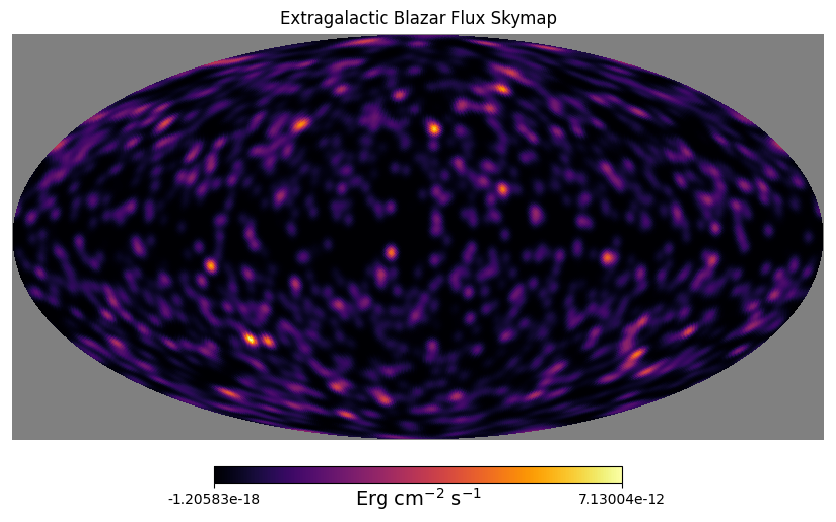

In [8]:
nside = 128
npix = hp.nside2npix(nside)

coords = SkyCoord(ra=LAT_RA*u.deg, dec=LAT_DEC*u.deg, frame='icrs')
l = coords.galactic.l.deg
b = coords.galactic.b.deg

theta = np.radians(90.0 - b)
phi = np.radians(l)

pix_indices = hp.ang2pix(nside, theta, phi)

flux_map = np.zeros(npix)
counts = np.zeros(npix)

for p, f in zip(pix_indices, LAT_Flux):
    flux_map[p] += f
    counts[p] += 1

flux_map[counts > 0] /= counts[counts > 0]

flux_map[counts == 0] = hp.UNSEEN

obs_map = flux_map
nside = hp.get_nside(obs_map)
beam_fwhm = np.radians(3.0)

lmax = 3 * nside - 1
alm = hp.map2alm(obs_map, lmax=lmax)

ls = np.arange(lmax+1)
sigma = beam_fwhm / np.sqrt(8 * np.log(2))
B_l = np.exp(-0.5 * ls * (ls + 1) * sigma**2)

B_l_safe = np.where(B_l < 1e-3, 1e-3, B_l)

alm_deconv = hp.almxfl(alm, 1.0 / B_l_safe)

deconv_map = hp.alm2map(alm_deconv, nside)

smoothed_map = hp.smoothing(deconv_map, fwhm=np.radians(5.0))  # smooth with 5° FWHM

stretch = 0.1
norm = mcolors.SymLogNorm(linthresh=stretch, vmin=np.min(smoothed_map), vmax=np.max(smoothed_map))

hp.mollview(smoothed_map,title='Extragalactic Blazar Flux Skymap',unit='Erg cm$^{-2}$ s$^{-1}$', cmap='inferno', norm=norm)

plt.savefig(outdir+'MeV_Flux_Sky_Map_Deconvolved_Smoothed.png', dpi=300)
plt.show()


In [9]:
Matched_Flux_Map = Table.read(catalog_dir + 'Masked_Matched_Flux_Map.fits')
Matched_Flux_Map.pprint_all()

          Name                  RA                 DEC             MeV_Flux_Total          MeV_Flux_0.2           MeV_Flux_0.5           MeV_Flux_1.0           MeV_Flux_2.0           MeV_Flux_5.0          MeV_Flux_10.0          MeV_Flux_20.0          MeV_Flux_50.0          MeV_Flux_100.0    
----------------------- ------------------ ------------------- ---------------------- ---------------------- ---------------------- ---------------------- ---------------------- ---------------------- ---------------------- ---------------------- ---------------------- ----------------------
            PKS 0202-17 31.263700485229492 -17.002199172973633  6.549515048096392e-05  5.444870276610817e-06  7.716645692702394e-06  9.404840321623919e-06 1.0829464830192435e-05 1.1959837541870043e-05 1.2069941318826312e-05 1.1508473967298091e-05  9.904060554086102e-06  8.276565900684799e-06
             S5 0212+73  34.35329818725586   73.88040161132812 0.00010883531747088851 1.4929753143768558e-05 1.8773699813

In [10]:
Matched_RA = np.array(Matched_Flux_Map['RA'].tolist())
Matched_DEC = np.array(Matched_Flux_Map['DEC'].tolist())
Matched_Flux = np.array(Matched_Flux_Map['MeV_Flux_Total'].tolist())
Matched_Names = np.array(Matched_Flux_Map['Name'].tolist())

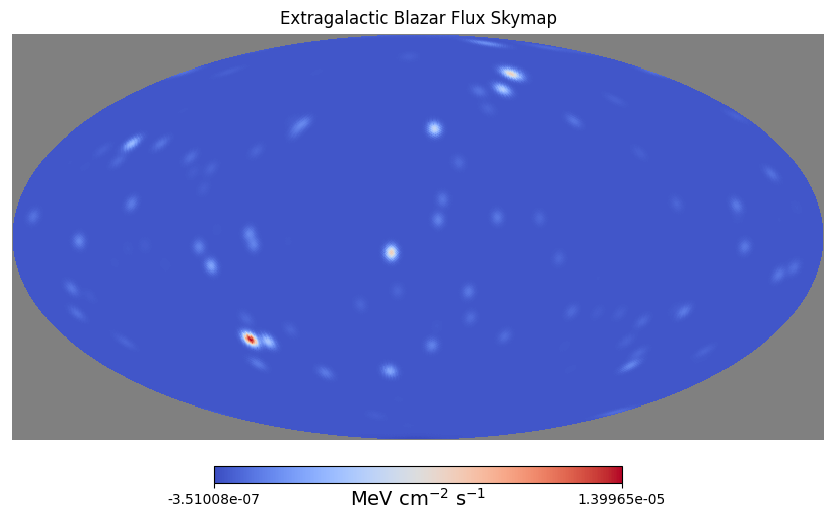

In [11]:
nside = 128
npix = hp.nside2npix(nside)

coords = SkyCoord(ra=Matched_RA*u.deg, dec=Matched_DEC*u.deg, frame='icrs')
l = coords.galactic.l.deg
b = coords.galactic.b.deg

theta = np.radians(90.0 - b)
phi = np.radians(l)

pix_indices = hp.ang2pix(nside, theta, phi)

flux_map = np.zeros(npix)
counts = np.zeros(npix)

for p, f in zip(pix_indices, Matched_Flux):
    flux_map[p] += f
    counts[p] += 1

flux_map[counts > 0] /= counts[counts > 0]

flux_map[counts == 0] = hp.UNSEEN

obs_map = flux_map
nside = hp.get_nside(obs_map)
beam_fwhm = np.radians(3.0)

lmax = 3 * nside - 1
alm = hp.map2alm(obs_map, lmax=lmax)

ls = np.arange(lmax+1)
sigma = beam_fwhm / np.sqrt(8 * np.log(2))
B_l = np.exp(-0.5 * ls * (ls + 1) * sigma**2)

B_l_safe = np.where(B_l < 1e-3, 1e-3, B_l)

alm_deconv = hp.almxfl(alm, 1.0 / B_l_safe)

deconv_map = hp.alm2map(alm_deconv, nside)

smoothed_map = hp.smoothing(deconv_map, fwhm=np.radians(5.0))  # smooth with 5° FWHM

stretch = 0.1
norm = mcolors.SymLogNorm(linthresh=stretch, vmin=np.min(smoothed_map), vmax=np.max(smoothed_map))

hp.mollview(smoothed_map,title='Extragalactic Blazar Flux Skymap',unit='MeV cm$^{-2}$ s$^{-1}$', cmap='coolwarm', norm=norm)

plt.savefig(outdir+'Matched_MeV_Flux_Sky_Map_Deconvolved_Smoothed.png', dpi=300)

In [12]:
Masked_Flux_Map_info = list(zip(Matched_Names, l, b, Matched_Flux))

largest_10 = sorted(Masked_Flux_Map_info, key=lambda x: x[3], reverse=True)[:10]
print(largest_10)

[(np.str_('3C 454.3'), np.float64(86.11854044311247), np.float64(-38.18486593770114), np.float64(0.0012089990564635457)), (np.str_('PKS 1830-211'), np.float64(12.166450470650767), np.float64(-5.704807843085155), np.float64(0.000707331755404115)), (np.str_('3C 273'), np.float64(289.93056798732573), np.float64(64.3510444989099), np.float64(0.000673671455967864)), (np.str_('PKS 1510-089'), np.float64(351.28754320971115), np.float64(40.131213205263), np.float64(0.00048381285946810456)), (np.str_('3C 279'), np.float64(305.09518543475014), np.float64(57.06318672536357), np.float64(0.0004109701937969717)), (np.str_('CTA 102'), np.float64(77.43849254960116), np.float64(-38.583152580279005), np.float64(0.00037841140637477323)), (np.str_('4C +71.07'), np.float64(143.54924020078866), np.float64(34.42446179950208), np.float64(0.00032425979941342004)), (np.str_('PKS 2149-306'), np.float64(17.082283860225935), np.float64(-50.77044084787796), np.float64(0.00024643529810231316)), (np.str_('BL Lac'), n

NSIDE = 64, NPIX = 49152, len(flux) = 1024


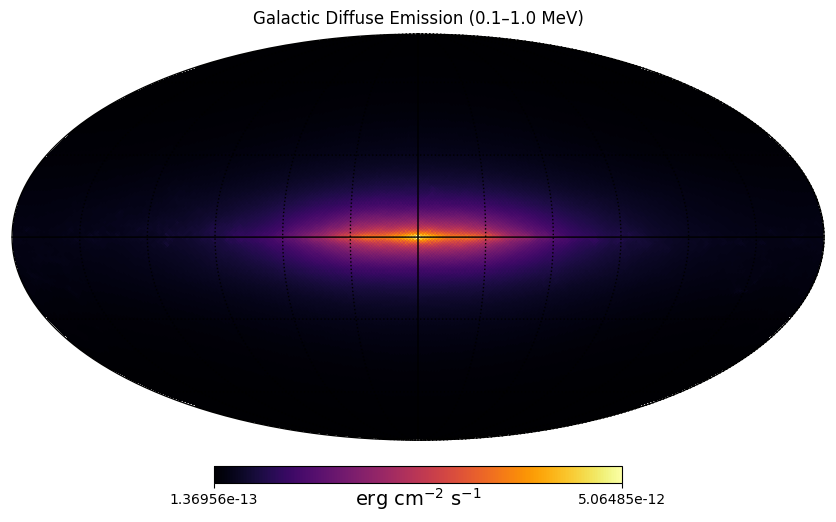

In [13]:
hdu = fits.open(catalog_dir + 'Skymap_Catalogs/GDEmap_Ackermann_0.1to1.0MeV.fits')
data = hdu[1].data

flux = data['Flux'][0]  
flux = flux.flatten()

nside = hdu[1].header['NSIDE']
npix = hp.nside2npix(nside)
print(f"NSIDE = {nside}, NPIX = {npix}, len(flux) = {len(flux)}")

flux_all = np.concatenate(data['Flux'])

hp.mollview(flux_all,  cmap='inferno', unit='erg cm$^{-2}$ s$^{-1}$',
            title='Galactic Diffuse Emission (0.1–1.0 MeV)')
hp.graticule()
plt.show()
